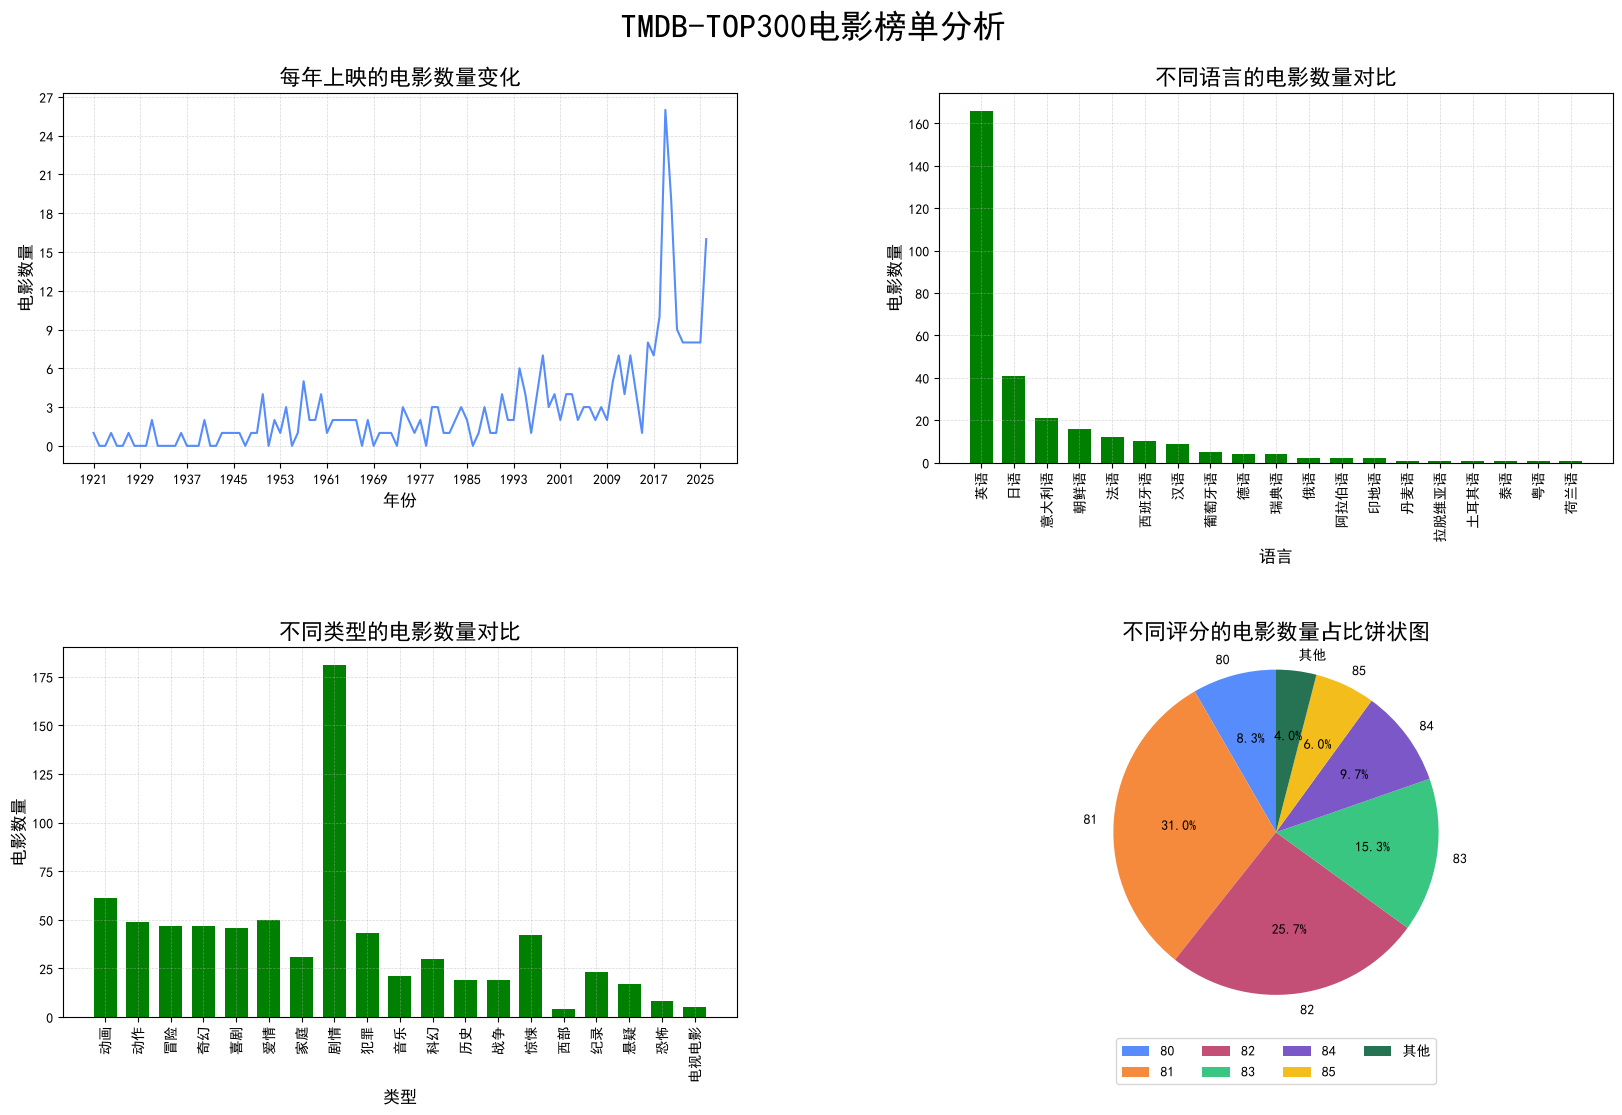

In [1]:
from matplotlib.axes import Axes
import pandas as pd
import matplotlib.pyplot as plt

# 显示中文
plt.rcParams['font.sans-serif'] = ['SimHei']

# 创建子图
fig, axes = plt.subplots(nrows=2,ncols=2,figsize=(20,12), dpi =100)
fig.suptitle('TMDB-TOP300电影榜单分析', fontsize=24, x=0.5, y=0.95)# 主标题,x=0.5:x轴位置, y=0.95:y轴位置
fig.subplots_adjust(hspace=0.5, wspace=0.3) # 调整子图之间的间距,hspace:垂直方向, wspace:水平方向

# 获取子图
axes1: Axes = axes[0][0]
axes2: Axes = axes[0][1]
axes3: Axes = axes[1][0]
axes4: Axes = axes[1][1]


# 读取数据
# int64 :整形数字(不支持空值)
# Int64 :整型数字(支持空值)
# float64 :浮点型数字(支持空值)
data = pd.read_csv('data/movie.csv', usecols = ['电影名','年份','上映时间','类型','时长','评分', '语言'])




# 需求1 : 统计TOP300的电影中, 每一年上映的电影数量的变化(折线图)
# 1.1 缺失值,异常值处理
data.isnull().sum()# 统计缺失值，都为0：表示没有缺失值；有缺失值时，会显示缺失值的个数。
# 比如有年份缺失
# data['年份'] = data['年份'].fillna(data['上映时间'].str[:4])

# 1.2 分组统计
year_count = data.groupby('年份')['年份'].count()

# 1.3 组装数据
# x轴数据
min_year = year_count.index.min()
max_year = year_count.index.max()
x = [i for i in range(min_year, max_year+1)] # x轴数据

# y轴数据
y = [int(year_count.get(i, 0)) for i in x] # y轴数据
y_ticks = [i for i in range(0, 30, 3)] # y轴刻度
# 绘制折线图
axes1.plot(x, y)# 绘制折线图
axes1.set_title('每年上映的电影数量变化', fontsize=16)# 添加子图标题
axes1.set_xlabel('年份', fontsize=12)# 设置x轴标签
axes1.set_ylabel('电影数量', fontsize=12)# 设置y轴标签
axes1.set_xticks(x[::8])# 设置x轴刻度
axes1.set_yticks(y_ticks)# 设置y轴刻度
axes1.grid(linestyle='--', alpha=0.5)# 添加网格


# 需求2 :统计对比不同语言的电影数量(柱状图)
# 2.1 获取不同语言对应的电影数量
language_count = data.groupby('语言')['语言'].count().sort_values(ascending=False)

x_language = language_count.index.tolist()# 获取x轴数据
y_language_count = language_count.values.tolist()# 获取y轴数据

# 2.2 绘制柱状图
axes2.bar(x_language, y_language_count, color = 'g', width=0.7)# 绘制柱状图
axes2.set_title('不同语言的电影数量对比', fontsize=16)# 添加子图标题
axes2.set_xlabel('语言', fontsize=12)# 设置x轴标签
axes2.set_ylabel('电影数量', fontsize=12)# 设置y轴标签
axes2.grid(linestyle='--', alpha=0.5)# 添加网格
axes2.tick_params(axis='x', rotation=90) # 旋转x轴标签



# 需求3 : 统计不同类型的电影数量(柱状图)
# 3.1 获取不同类型的电影数量
type_count = {} # {'剧情': 3, '动作': 2, '喜剧': 1}
for types in data['类型'].str.split(","): # [剧情, 动作]
    for type in types:
        if type in type_count:
            type_count[type] += 1
        else:
            type_count[type] = 1
x_types = list(type_count.keys()) # 获取x轴数据 list() : 将字典的键转换为列表
y_values = list(type_count.values())# 获取y轴数据

# 3.2 绘制柱状图
axes3.bar(x_types, y_values, color = 'g', width=0.7)# 绘制柱状图
axes3.set_title('不同类型的电影数量对比', fontsize=16)# 添加子图标题
axes3.set_xlabel('类型', fontsize=12)# 设置x轴标签
axes3.set_ylabel('电影数量', fontsize=12)# 设置y轴标签
axes3.grid(linestyle='--', alpha=0.5)# 添加网格
axes3.tick_params(axis='x', rotation=90) # 旋转x轴标签


# 需求4 : 统计不同评分的电影数量(饼状图)
# 4.1 获取不同评分的电影数量
scores_count = data.groupby('评分')['评分'].count()

# 合并小数据
total = scores_count.sum()
large_scores = scores_count.loc[scores_count > total * 0.02]# 大数据, 占比大于2%
small_scores = scores_count.loc[scores_count <= total * 0.02] # 小数据, 占比小于等于2%

# if small_scores.shape[0] > 0:   shape[0] : 获取小数据的行数, shape[1] : 获取小数据的列数 ,Series只有行数, DataFrame才有行数和列数
# 如果小数据不为空，属于数值判断
if not small_scores.empty: # 如果小数据不为空，属于逻辑判断
    large_scores['其他'] = small_scores.sum()



x_scores = large_scores.index.tolist() # 评分列表
y_scores = large_scores.values.tolist() # 评分对应的电影数量列表

# 4.2 绘制饼图
axes4.pie(y_scores, labels=x_scores, autopct='%1.1f%%', startangle=90, radius=1.1) # autopct='%1.1f%%' : 显示百分比; startangle=90 : 起始角度
axes4.set_title('不同评分的电影数量占比饼状图', fontsize=16) # 添加子图标题
axes4.legend(loc='lower center',ncol=4, bbox_to_anchor=(0.5, -0.2))# 添加图例

# 5. 保存图片
plt.savefig('data/TMDB-TOP300.png')

plt.show() # 显示画布




